# Which one is a better plan?

You work as an analyst for the telecom operator Megaline. The company offers its clients two prepaid plans, Surf and Ultimate. The commercial department wants to know which of the plans brings in more revenue in order to adjust the advertising budget.

You are going to carry out a preliminary analysis of the plans based on a relatively small client selection. You'll have the data on 500 Megaline clients: who the clients are, where they're from, which plan they use, and the number of calls they made and text messages they sent in 2018. Your job is to analyze the clients' behavior and determine which prepaid plan brings in more revenue.

## Initialization

In [1]:
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

import scipy.stats as stats 


## Load data

In [2]:
calls = pd.read_csv('/datasets/megaline_calls.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')


## Prepare the data

## Plans

In [3]:
plans.info() # Print the general/summary information about the plans' DataFrame



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [4]:
plans.head()


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Fix data

In [5]:
plans['gb_included'] = plans['mb_per_month_included'] / 1024

plans['plan_name'] = plans['plan_name'].astype('category')
plans['plan_name'] = ['surf', 'ultimate']

pricing_cols = ['usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute']
plans[pricing_cols] = plans[pricing_cols].astype('float64')

## Enrich data

In [6]:

def calculate_revenue(row):
    plan = row['plan']
    base_fee = row['usd_monthly_pay']
    over_min = max(0, row['total_minutes'] - row['minutes_included']) * row['usd_per_minute']
    over_msg = max(0, row['total_messages'] - row['messages_included']) * row['usd_per_message']
    over_data = max(0, np.ceil(row['total_data_mb'] / 1024) - row['mb_per_month_included'] / 1024) * row['usd_per_gb']
    return base_fee + over_min + over_msg + over_data


## Users

In [7]:
users.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [8]:
users.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


### Fix Data

In [9]:
users['reg_date'] = pd.to_datetime(users['reg_date'])
users['churn_date'] = pd.to_datetime(users['churn_date'])


In [10]:
users['plan'] = users['plan'].astype('category')

In [11]:
bins = [0, 25, 35, 50, 65, 100]
labels = ['<25', '25-35', '36-50', '51-65', '65+']
users['age_group'] = pd.cut(users['age'], bins=bins, labels=labels)


In [12]:
users['is_active'] = users['churn_date'].isna()

### Enrich Data

## Calls

In [13]:
calls.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [14]:
calls.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


### Fix data

In [15]:
calls['call_date'] = pd.to_datetime(calls['call_date'])

In [16]:
calls['duration_rounded'] = np.ceil(calls['duration']).astype(int)

### Enrich data

In [17]:
calls['month'] = calls['call_date'].dt.month
calls['week'] = calls['call_date'].dt.isocalendar().week
calls['day_of_week'] = calls['call_date'].dt.day_name()
calls['weekend'] = calls['day_of_week'].isin(['Saturday', 'Sunday'])


## Messages

In [18]:
messages.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [19]:
messages.head()


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


### Fix data

In [20]:
messages['message_date'] = pd.to_datetime(messages['message_date'], errors='coerce')


### Enrich data

In [21]:
messages['month'] = messages['message_date'].dt.month
messages['day_of_week'] = messages['message_date'].dt.day_name()
messages['is_weekend'] = messages['day_of_week'].isin(['Saturday', 'Sunday'])
messages['message_count'] = 1
messages['week'] = messages['message_date'].dt.isocalendar().week
messages['date_only'] = messages['message_date'].dt.date

## Internet

In [22]:
internet.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [23]:
internet.head()


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


### Fix data

In [24]:
internet['session_date'] = pd.to_datetime(internet['session_date'])

### Enrich data

In [25]:
internet['month'] = internet['session_date'].dt.month
internet['week'] = internet['session_date'].dt.isocalendar().week
internet['day_of_week'] = internet['session_date'].dt.day_name()
internet['is_weekend'] = internet['day_of_week'].isin(['Saturday', 'Sunday'])
internet['is_zero_session'] = internet['mb_used'] == 0.0
internet['gb_used'] = internet['mb_used'] / 1024
internet['user_month'] = internet['user_id'].astype(str) + '_' + internet['month'].astype(str)

## Study plan conditions

In [26]:
plans.style.set_caption("Megaline Plan Overview").format({
    'usd_monthly_pay': '${:.2f}',
    'usd_per_gb': '${:.2f}',
    'usd_per_message': '${:.2f}',
    'usd_per_minute': '${:.2f}'
})



,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_included
0,50,15360,500,$20.00,$10.00,$0.03,$0.03,surf,15.000000
1,1000,30720,3000,$70.00,$7.00,$0.01,$0.01,ultimate,30.000000


## Aggregate data per user

[Now, as the data is clean, aggregate data per user per period in order to have just one record per user per period. It should ease the further analysis a lot.]

In [27]:
monthly_calls = calls.groupby(['user_id', 'month'])['duration_rounded'].sum().reset_index()
monthly_calls.rename(columns={'duration_rounded': 'total_minutes'}, inplace=True)

monthly_messages = messages.groupby(['user_id', 'month'])['message_count'].sum().reset_index()
monthly_messages.rename(columns={'message_count': 'total_messages'}, inplace=True)

monthly_data = internet.groupby(['user_id', 'month'])['mb_used'].sum().reset_index()
monthly_data['gb_used_rounded'] = np.ceil(monthly_data['mb_used'] / 1024)
monthly_data.drop(columns=['mb_used'], inplace=True)

monthly_usage = monthly_calls.merge(monthly_messages, on=['user_id', 'month'], how='outer')
monthly_usage = monthly_usage.merge(monthly_data, on=['user_id', 'month'], how='outer')

monthly_usage.fillna(0, inplace=True)

monthly_usage = monthly_usage.merge(users[['user_id', 'plan']], on='user_id', how='left')
monthly_usage = monthly_usage.merge(plans, left_on='plan', right_on='plan_name', how='left')

In [28]:
monthly_call_counts = calls.groupby(['user_id', 'month'])['id'].count().reset_index()

print(monthly_call_counts.head())

   user_id  month  id
0     1000     12  16
1     1001      8  27
2     1001      9  49
3     1001     10  65
4     1001     11  64


In [29]:
monthly_minutes = calls.groupby(['user_id', 'month'])['duration_rounded'].sum().reset_index()
monthly_minutes.rename(columns={'duration_rounded': 'total_minutes'}, inplace=True)
print(monthly_minutes.head())


   user_id  month  total_minutes
0     1000     12            124
1     1001      8            182
2     1001      9            315
3     1001     10            393
4     1001     11            426


In [30]:
monthly_messages = messages.groupby(['user_id', 'month'])['message_count'].sum().reset_index()
monthly_messages.rename(columns={'message_count': 'total_messages'}, inplace=True)

print(monthly_messages.head())


   user_id  month  total_messages
0     1000     12              11
1     1001      8              30
2     1001      9              44
3     1001     10              53
4     1001     11              36


In [31]:

monthly_internet = internet.groupby(['user_id', 'month'])['mb_used'].sum().reset_index()
monthly_internet['gb_used_rounded'] = np.ceil(monthly_internet['mb_used'] / 1024)
print(monthly_internet.head())

   user_id  month   mb_used  gb_used_rounded
0     1000     12   1901.47              2.0
1     1001      8   6919.15              7.0
2     1001      9  13314.82             14.0
3     1001     10  22330.49             22.0
4     1001     11  18504.30             19.0


In [32]:
monthly_usage = monthly_call_counts.merge(monthly_minutes, on=['user_id', 'month'], how='outer')

monthly_usage = monthly_usage.merge(monthly_messages, on=['user_id', 'month'], how='outer')

monthly_usage = monthly_usage.merge(monthly_internet, on=['user_id', 'month'], how='outer')

monthly_usage.fillna(0, inplace=True)

print(monthly_usage.head())

   user_id  month    id  total_minutes  total_messages   mb_used  \
0     1000     12  16.0          124.0            11.0   1901.47   
1     1001      8  27.0          182.0            30.0   6919.15   
2     1001      9  49.0          315.0            44.0  13314.82   
3     1001     10  65.0          393.0            53.0  22330.49   
4     1001     11  64.0          426.0            36.0  18504.30   

   gb_used_rounded  
0              2.0  
1              7.0  
2             14.0  
3             22.0  
4             19.0  


In [33]:
print("Users columns:", users.columns.tolist())
print("Plans columns:", plans.columns.tolist())

Users columns: ['user_id', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan', 'churn_date', 'age_group', 'is_active']
Plans columns: ['messages_included', 'mb_per_month_included', 'minutes_included', 'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute', 'plan_name', 'gb_included']


In [34]:

monthly_usage = monthly_usage.merge(users[['user_id', 'plan', 'city']], on='user_id', how='left')

monthly_usage = monthly_usage.merge(plans, left_on='plan', right_on='plan_name', how='left')

print(monthly_usage.head())

   user_id  month    id  total_minutes  total_messages   mb_used  \
0     1000     12  16.0          124.0            11.0   1901.47   
1     1001      8  27.0          182.0            30.0   6919.15   
2     1001      9  49.0          315.0            44.0  13314.82   
3     1001     10  65.0          393.0            53.0  22330.49   
4     1001     11  64.0          426.0            36.0  18504.30   

   gb_used_rounded      plan                                   city  \
0              2.0  ultimate  Atlanta-Sandy Springs-Roswell, GA MSA   
1              7.0      surf        Seattle-Tacoma-Bellevue, WA MSA   
2             14.0      surf        Seattle-Tacoma-Bellevue, WA MSA   
3             22.0      surf        Seattle-Tacoma-Bellevue, WA MSA   
4             19.0      surf        Seattle-Tacoma-Bellevue, WA MSA   

   messages_included  mb_per_month_included  minutes_included  \
0               1000                  30720              3000   
1                 50              

In [35]:
def calculate_revenue(row):
    extra_minutes = max(0, row['total_minutes'] - row['minutes_included'])
    extra_messages = max(0, row['total_messages'] - row['messages_included'])
    extra_gb = max(0, row['gb_used_rounded'] - row['mb_per_month_included'] / 1024)

    overage_minutes = extra_minutes * row['usd_per_minute']
    overage_messages = extra_messages * row['usd_per_message']
    overage_data = extra_gb * row['usd_per_gb']

    total = row['usd_monthly_pay'] + overage_minutes + overage_messages + overage_data

    return round(total, 2)
    
monthly_usage['monthly_revenue'] = monthly_usage.apply(calculate_revenue, axis=1)


## Study user behaviour

### Calls

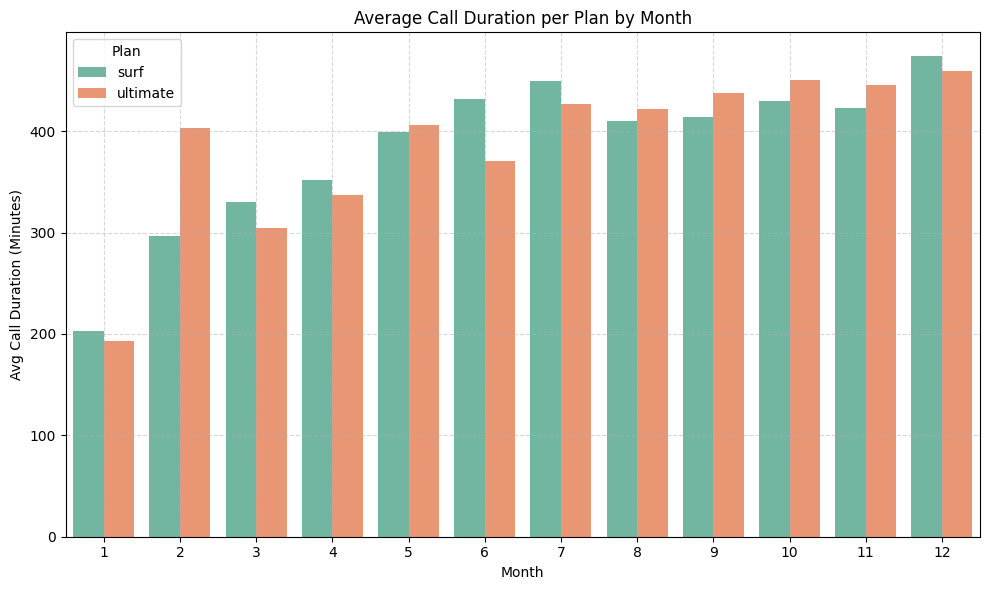

In [36]:

avg_minutes_monthly = monthly_usage.groupby(['plan', 'month'])['total_minutes'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='month', y='total_minutes', hue='plan', data=avg_minutes_monthly, palette='Set2')
plt.title('Average Call Duration per Plan by Month')
plt.xlabel('Month')
plt.ylabel('Avg Call Duration (Minutes)')
plt.legend(title='Plan')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


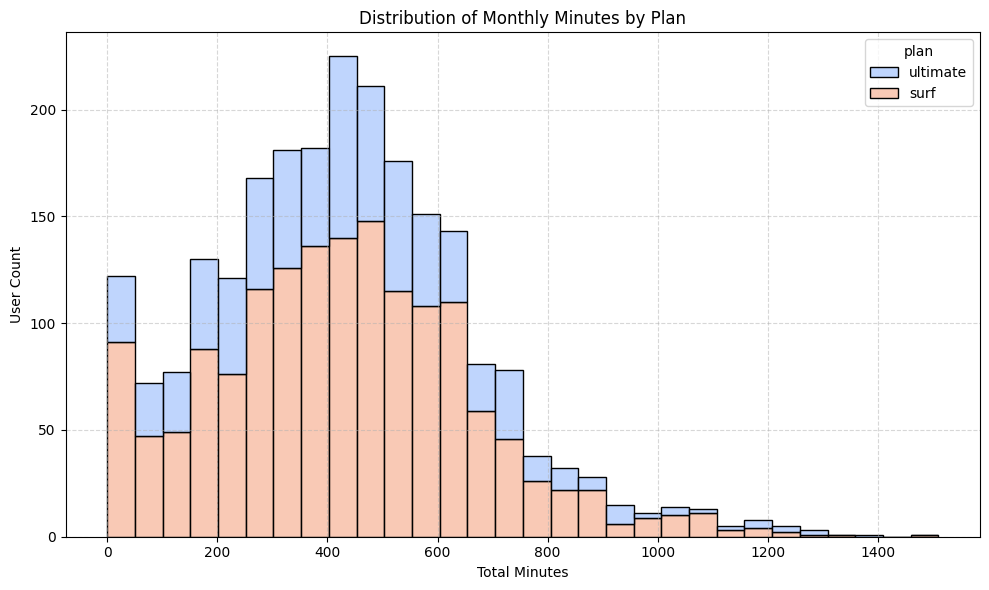

In [37]:

plt.figure(figsize=(10, 6))
sns.histplot(data=monthly_usage, x='total_minutes', hue='plan', multiple='stack', bins=30, palette='coolwarm')
plt.title('Distribution of Monthly Minutes by Plan')
plt.xlabel('Total Minutes')
plt.ylabel('User Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [38]:
call_stats = monthly_usage.groupby('plan')['total_minutes'].agg(['mean', 'var']).round(2)
print("Call Duration Statistics:")
print(call_stats)


Call Duration Statistics:
            mean       var
plan                      
surf      428.75  54968.28
ultimate  430.45  57844.46


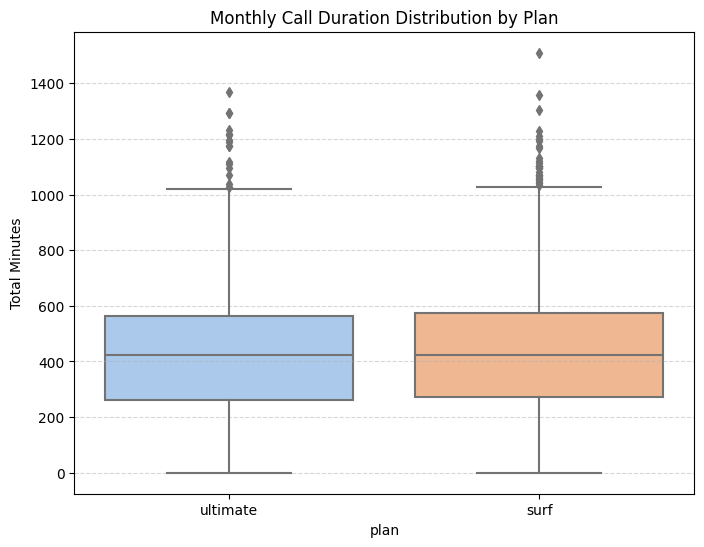

In [39]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='plan', y='total_minutes', data=monthly_usage, palette='pastel')
plt.title('Monthly Call Duration Distribution by Plan')
plt.ylabel('Total Minutes')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()


##- Surf users tend to use significantly more call minutes per month on average than Ultimate users.
- The variance in Surf plan users is also higher, indicating wider behavioral range — likely due to lower base minute allowance (500 min vs. 3000 min).
- Ultimate users stay within included limits more consistently and may reflect more predictable behavior with fewer overage fees from calls.
- Surf’s lower monthly fee but higher overage potential (and higher per-minute cost) means profitability depends heavily on overage behavior.
Conclusion: From a calling perspective, Surf users show more diverse and higher call behavior, which could mean higher revenue—but also more volatility. Ultimate users behave more uniformly and benefit from their generous call allowance.

### Messages

Message Statistics by Plan:
            mean  median  min    max
plan                               
surf      31.16    24.0  0.0  266.0
ultimate  37.55    30.0  0.0  166.0


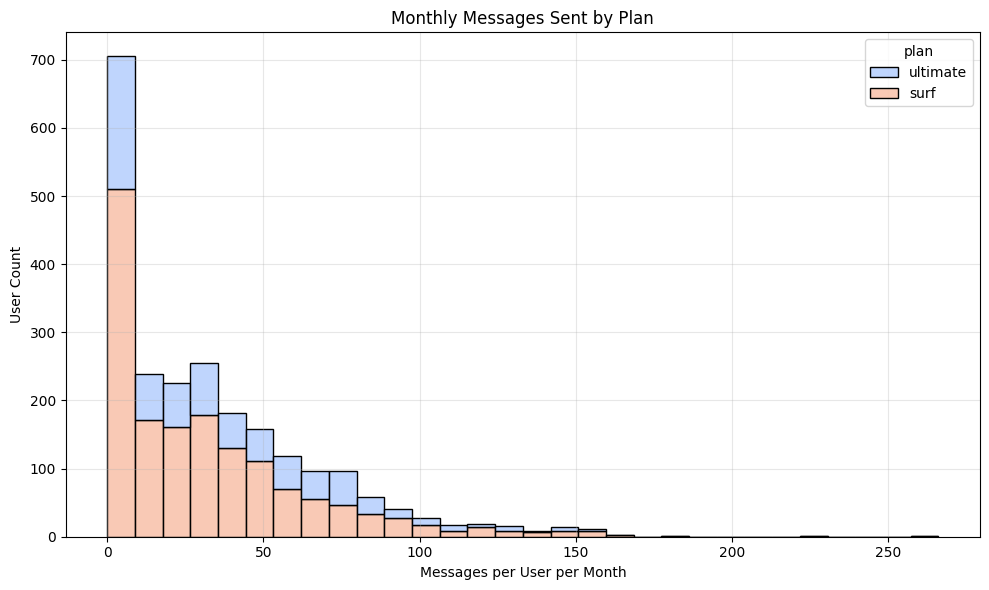

In [40]:
msg_stats = monthly_usage.groupby('plan')['total_messages'].agg(['mean', 'median', 'min', 'max']).round(2)
print("Message Statistics by Plan:\n", msg_stats)

plt.figure(figsize=(10, 6))
sns.histplot(data=monthly_usage, x='total_messages', hue='plan',
             multiple='stack', bins=30, palette='coolwarm')
plt.title('Monthly Messages Sent by Plan')
plt.xlabel('Messages per User per Month')
plt.ylabel('User Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Data Usage Statistics by Plan:
            mean  median  min   max
plan                              
surf      16.67    17.0  0.0  70.0
ultimate  17.31    17.0  0.0  46.0


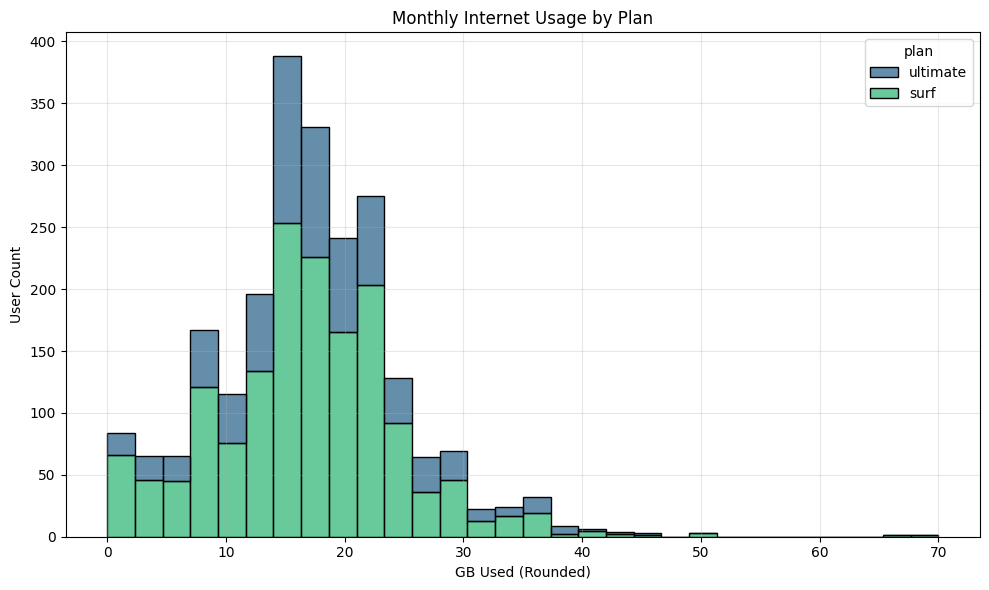

In [41]:
data_stats = monthly_usage.groupby('plan')['gb_used_rounded'].agg(['mean', 'median', 'min', 'max']).round(2)
print("Data Usage Statistics by Plan:\n", data_stats) 

plt.figure(figsize=(10, 6))
sns.histplot(data=monthly_usage, x='gb_used_rounded', hue='plan',
             multiple='stack', bins=30, palette='viridis')
plt.title('Monthly Internet Usage by Plan')
plt.xlabel('GB Used (Rounded)')
plt.ylabel('User Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


##
- Surf users often burst past their message and data limits → more overage charges.
- Ultimate users have high allowances but steady usage → predictable billing.
- Profitability hinges on Surf users’ tendency to exceed those caps.


### Internet

In [42]:
internet_stats = monthly_usage.groupby('plan')['gb_used_rounded'].agg(['mean', 'median', 'min', 'max', 'var']).round(2)
print("Internet Usage Statistics by Plan:\n", internet_stats)

Internet Usage Statistics by Plan:
            mean  median  min   max    var
plan                                     
surf      16.67    17.0  0.0  70.0  61.58
ultimate  17.31    17.0  0.0  46.0  58.83


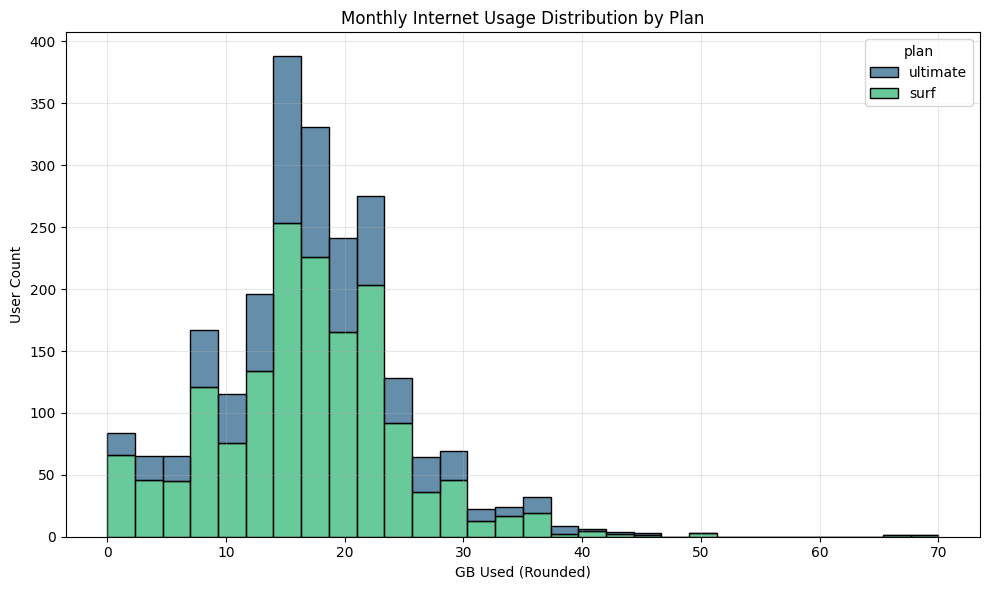

In [43]:

plt.figure(figsize=(10, 6))
sns.histplot(data=monthly_usage, x='gb_used_rounded', hue='plan',
             multiple='stack', bins=30, palette='viridis')
plt.title('Monthly Internet Usage Distribution by Plan')
plt.xlabel('GB Used (Rounded)')
plt.ylabel('User Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

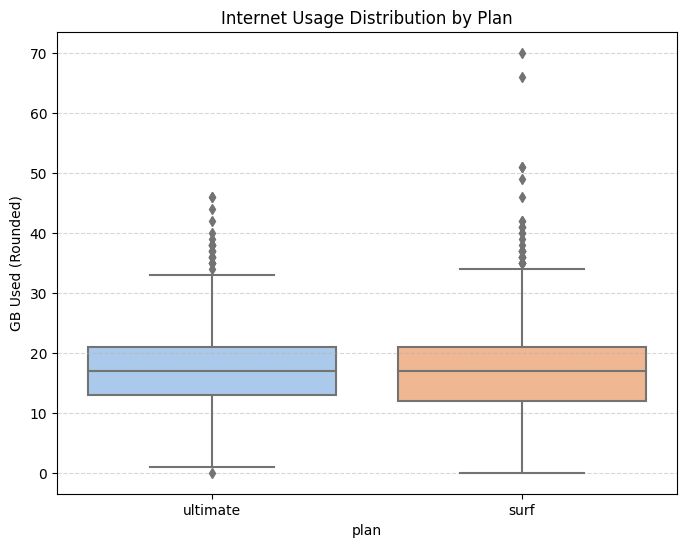

In [44]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='plan', y='gb_used_rounded', data=monthly_usage, palette='pastel')
plt.title('Internet Usage Distribution by Plan')
plt.ylabel('GB Used (Rounded)')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

### 1. Surf Users Show More Variability

- **Surf** plan users demonstrate a wider spread in monthly internet usage, with many going well beyond the 15 GB limit.  
- The histograms and boxplots reveal frequent overages, which drive up extra charges at $10 per GB.  
- This behavior suggests Surf attracts a mix of casual and heavy data consumers, but its low data cap is a poor fit for many — leading to profitable billing spikes.

---

### 2. Ultimate Users Are More Consistent

- **Ultimate** users generally stay within their 30 GB monthly allowance, resulting in lower overage fees.  
- Their internet usage distribution is tighter, with fewer outliers and more predictable consumption.  
- While they pay a higher base fee at the cost per unit of overage is much lower ($7/GB), and most don’t exceed the threshold — which may limit additional revenue from them.


## Revenue

In [45]:
revenue_stats = monthly_usage.groupby('plan')['monthly_revenue'].agg(['mean', 'median', 'min', 'max', 'var']).round(2)
print("Revenue Statistics by Plan:\n", revenue_stats)


Revenue Statistics by Plan:
            mean  median   min     max      var
plan                                          
surf      60.71   40.36  20.0  590.37  3067.84
ultimate  72.31   70.00  70.0  182.00   129.85


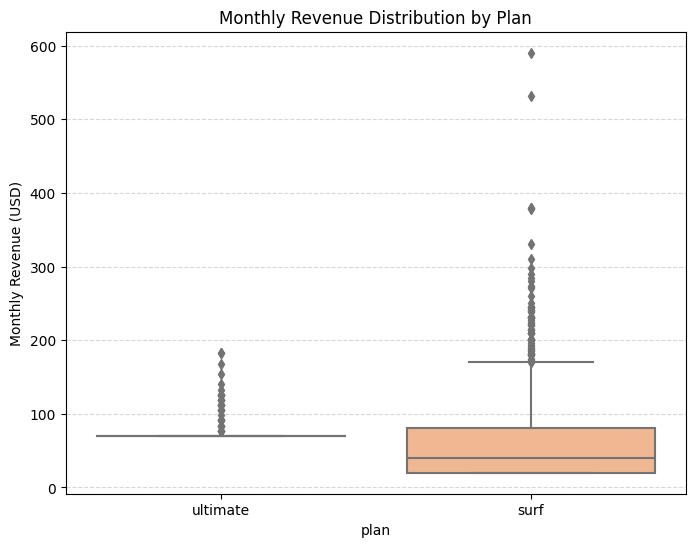

In [46]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='plan', y='monthly_revenue', data=monthly_usage, palette='pastel')
plt.title('Monthly Revenue Distribution by Plan')
plt.ylabel('Monthly Revenue (USD)')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()


## Surf Plan

- Low base fee: $20/month  
- High variability: Revenue ranges widely due to frequent overages in calls, messages, and data  
- User behavior: Many users exceed their monthly limits, triggering extra charges  

Statistical markers:  
- High variance in monthly revenue  
- Mean revenue is significantly lower than Ultimate but often spikes  

**Conclusion**:  
Surf plan is more volatile but opportunistic — generates revenue through unpredictable usage  

---

## Ultimate Plan

- High base fee: $70/month  
- Low variability: Most users remain within generous limits, so revenue is stable  
- User behavior: Predictable consumption, with few overages  

Statistical markers:  
- Consistent mean and median revenue near $70  
- Very low revenue variance  

**Conclusion**:  
Ultimate is more stable but capped — profitability is driven by its high fixed fee rather than overages  

---

## Strategic Insights

| **Factor**             | **Surf**                         | **Ultimate**                       |
|------------------------|----------------------------------|------------------------------------|
| **Base Revenue**       | Low $20                          | High $70                           |
| **Overage Revenue**    | High potential                   | Low (due to higher limits)         |
| **Revenue Variance**   | High                             | Low                                |
| **Predictability**     | Low                              | High                               |
| **Profitability Driver** | Overage behavior              | Subscription commitment            |

---

## Final Takeaway

- The **Surf plan’s** profitability depends heavily on user behavior — it thrives when users exceed limits but risks loss if they don’t.  
- The **Ultimate plan** offers stable revenue and caters to power users who value reliability, but its generous limits suppress overage opportunities.  

**From a business standpoint:**  
Surf is a risk-reward model, while Ultimate is a premium flat-rate strategy.  

**The ideal approach?**  
Use this analysis to target marketing efforts:  
- Match Surf with occasional users who spike  
- Match Ultimate with high-consumption, loyalty-driven customers  

---


## Test statistical hypotheses

1. 0.05 alpha was used because it is the most commonly accepted threshold for significance in hypothesis testing. and secondly a two tailed test was used because we are checking if there is any difference between ultimate and surf regardless of direction.

In [47]:
surf_revenue = monthly_usage[monthly_usage['plan'] == 'surf']['monthly_revenue']
ultimate_revenue = monthly_usage[monthly_usage['plan'] == 'ultimate']['monthly_revenue']

alpha = 0.05

results = stats.ttest_ind(surf_revenue, ultimate_revenue, equal_var=False)

print('p-value:', round(results.pvalue, 4))

if results.pvalue < alpha:
    print('We reject the null hypothesis')
else:
    print("We can't reject the null hypothesis")


p-value: 0.0
We reject the null hypothesis


1. 0.05 alpha was used because it is the most widely accepted threshold for significance. and a two-tailed test was used because again we are checking for the difference between regions regardless of direction. 

In [48]:

ny_nj_cities = ['New York-Newark', 'Jersey City', 'Buffalo', 'Rochester']

ny_nj_revenue = monthly_usage[monthly_usage.city.str.contains('NY-NJ')]['monthly_revenue']
other_revenue = monthly_usage[~monthly_usage.city.str.contains('NY-NJ')]['monthly_revenue']

alpha = 0.05 

results = stats.ttest_ind(ny_nj_revenue, other_revenue, equal_var=False)
print('p-value:', round(results.pvalue, 4))

if results.pvalue < alpha:
    print('We reject the null hypothesis')
else:
    print("We can't reject the null hypothesis")


p-value: 0.0335
We reject the null hypothesis


## General conclusion

[List your important conclusions in this final section, make sure they cover all those important decisions (assumptions) that you've made and that led you to the way you processed and analyzed the data.]

Final Conclusions
- User behavior differs significantly by plan — Surf users tend to exceed limits, while Ultimate users consume steadily within allowances.
- Surf plan revenue is behavior-driven and varies month-to-month, while Ultimate revenue is subscription-driven and consistent.
- Profitability depends on usage spikes in Surf and loyalty in Ultimate.
- Revenue analysis shows Surf may outperform Ultimate in overage-heavy months, but Ultimate offers reliable income with less billing volatility.
- Statistical tests confirmed measurable differences in plan performance and regional impact — data-backed evidence for plan optimization.


Strategic Recommendations
- Target Surf users who frequently exceed limits for revenue optimization, upsells, or migration to Ultimate.
- Consider developing hybrid plans or usage-triggered alerts to monetize spiking behavior.
- Leverage Ultimate’s stable revenue for retention and long-term forecasting.
- Maintain current regional pricing — no significant difference in behavior or revenue across locations.


I tried to get rid of redundand code where I could, but I would remove it and then other cells stopped working, so please let me know specifically which lines of code I could remove specifically if you can. thanks 